<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/Carena_Fig5_mainpy_nonexpert_report_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GN Model 보고서: PSCF·SMF·NZDSF의 최대 전송거리 계산

이 보고서는 Carena et al. 논문의 Figure 5 기준점과 `main.py`의 GN model 계산값을 비교합니다. 계산 엔진은 GitHub의 `2026_KICS_Fall/main.py` 한 파일이며, 논문값에 맞추기 위한 fitting은 하지 않습니다.

**이 노트북에서 확인할 내용**

1. PSCF, SMF, NZDSF에 어떤 광섬유 숫자를 입력했는가
2. 공통 시스템 조건은 무엇인가
3. `main.py`가 어떻게 최대 전송거리를 고르는가
4. 논문 Figure 5 기준점과 계산값의 차이는 어느 정도인가


## 먼저 알아둘 점: 이 계산은 fitting이 아닙니다

- 광섬유별 손실, 분산, 비선형계수와 논문의 시스템 조건을 `main.py`에 입력합니다.
- `main.py`가 ASE 잡음과 비선형 잡음을 계산한 뒤, SNR 기준을 만족하는 가장 긴 거리를 찾습니다.
- 논문 Figure 5 값은 계산을 바꾸는 데 쓰지 않고, 계산이 끝난 뒤 오차율을 구하는 비교 기준으로만 사용합니다.
- Figure 5 기준점은 원 논문의 raw 데이터가 아니라, 저장소에 정리한 digitized/rounded 값입니다.


## 결론

본 연구에서는 main.py 기반 GN 모델을 이용하여 PSCF, SMF, NZDSF 광섬유의 최대 전송거리를 계산하였다. 비교 대상인 Carena et al. 논문은 광섬유 내 비선형 잡음을 해석적으로 계산하는 GN 모델의 성능을 다양한 광섬유와 변조방식 조건에서 컴퓨터 시뮬레이션 결과와 비교한 논문이다.

본 코드에는 각 광섬유의 손실, 분산, 비선형계수와 채널 수, 증폭기 잡음, span 길이 등을 입력하였다. 이후 입력 전력과 전송거리를 바꿔가며 신호 품질을 계산하고, 통신에 필요한 최소 품질을 만족하는 가장 먼 거리를 최대 전송거리로 선택하였다.

논문의 Figure 5 기준값과 비교한 결과, PSCF·SMF·NZDSF 총 63개 조건에서 평균 절대오차는 약 **7.4%**였다. 이는 본 코드가 해당 조건에서 광섬유 종류에 따른 전송거리 차이와 최적 운용 경향을 비교적 잘 추정한다는 의미이다.

따라서 본 GN 모델은 광섬유 종류 비교, launch power 변화에 따른 신호 품질 비교, span 길이 및 리피터 수의 초기 검토, 전송 용량의 상대 비교에 활용할 수 있다. 다만 이 결과는 논문 Figure 5의 판독·반올림 기준값과 비교한 것이므로, 실제 장거리 전송 시스템의 최종 설계값을 확정하기보다는 설계 초기 단계의 예측 및 비교 도구로 활용하는 것이 적절하다.


In [1]:
# Colab 또는 로컬 환경에서 최신 main.py를 준비합니다.
from pathlib import Path
from urllib.request import urlretrieve
import sys

# 이 보고서에서 검증한 main.py 버전입니다.
MAIN_PY_COMMIT = '33d39afd2ccf0fc7875403200be56bc1fce6a82e'
MAIN_PY_URL = (
    'https://raw.githubusercontent.com/kimheeseo/LSCNS/'
    f'{MAIN_PY_COMMIT}/2026_KICS_Fall/main.py'
)
main_py_path = Path('main.py')

# Colab에서는 항상 GitHub 버전을 받습니다.
# 로컬에서 실행할 때 같은 폴더에 main.py가 있으면 그것을 그대로 사용합니다.
if 'google.colab' in sys.modules or not main_py_path.exists():
    urlretrieve(MAIN_PY_URL, main_py_path)
    print(f'GitHub의 main.py를 준비했습니다: {MAIN_PY_COMMIT}')
else:
    print(f'로컬 main.py를 사용합니다: {main_py_path.resolve()}')

# 이전 실행에서 import된 모듈을 지우고 현재 파일을 다시 읽습니다.
sys.modules.pop('main', None)


GitHub의 main.py를 준비했습니다: 33d39afd2ccf0fc7875403200be56bc1fce6a82e


In [2]:
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

from main import (
    FIG5_BITS_PER_SYMBOL,
    FIG5_FIBER_INPUTS,
    FIG5_REQUIRED_OSNR_DB_PER_0P1NM,
    FiberParameters,
    GNOptions,
    SystemParameters,
    _plot_carena_fig5,
    save_carena_fig5_result,
    validate_carena_fig5,
)

pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')


## 1. 계산 흐름을 쉬운 말로 보기

광신호는 거리가 길어질수록 약해지고, 증폭기는 신호와 함께 잡음도 더합니다. 또한 광신호의 세기가 너무 크면 광섬유 안에서 신호끼리 서로 영향을 주어 비선형 잡음이 생깁니다.

`main.py`는 각 launch power와 거리에서 다음을 반복합니다.

1. 광섬유 손실만큼 증폭기가 필요한 이득을 계산합니다.
2. 증폭기에서 생기는 ASE 잡음과 광섬유에서 생기는 비선형 잡음(NLI)을 계산합니다.
3. `SNR = 신호 / (ASE 잡음 + 비선형 잡음)`을 계산합니다.
4. 변조방식이 요구하는 최소 SNR보다 큰 거리 중 가장 먼 곳을 선택합니다.
5. 선택된 span 수에 100 km를 곱해 최대 전송거리로 표시합니다.


In [3]:
calculation_flow = pd.DataFrame([
    ['입력', '광섬유의 손실·분산·비선형계수, 채널 수, 증폭기 NF'],
    ['잡음 계산', '각 span마다 ASE 잡음과 비선형 잡음을 계산'],
    ['품질 판단', '계산 SNR이 변조방식별 최소 SNR 이상인지 확인'],
    ['거리 선택', '조건을 만족하는 가장 큰 span 수 × 100 km'],
    ['검증', '논문 Figure 5 기준점과 비교해 오차율 계산'],
], columns=['단계', 'main.py가 하는 일'])
display(calculation_flow)


,단계,main.py가 하는 일
0,입력,"광섬유의 손실·분산·비선형계수, 채널 수, 증폭기 NF"
1,잡음 계산,각 span마다 ASE 잡음과 비선형 잡음을 계산
2,품질 판단,계산 SNR이 변조방식별 최소 SNR 이상인지 확인
3,거리 선택,조건을 만족하는 가장 큰 span 수 × 100 km
4,검증,논문 Figure 5 기준점과 비교해 오차율 계산


## 2. PSCF·SMF·NZDSF에 넣은 광섬유 입력값

아래 세 숫자가 광섬유별 차이입니다.

- **손실(dB/km)**: 작을수록 신호가 덜 약해져 장거리 전송에 유리합니다.
- **분산(ps/nm/km)**: 채널들이 서로 겹쳐 영향을 주는 정도에 관계됩니다. 이 GN 계산에서는 분산이 큰 편이 비선형 잡음 억제에 유리할 수 있습니다.
- **비선형계수 γ (1/W/km)**: 클수록 높은 광세기에서 비선형 잡음이 커집니다.


In [4]:
fiber_inputs = (
    pd.DataFrame(FIG5_FIBER_INPUTS).T
    .rename(columns={
        'attenuation_db_per_km': '손실 (dB/km)',
        'dispersion_ps_nm_km': '분산 (ps/nm/km)',
        'gamma_per_w_km': '비선형계수 γ (1/W/km)',
    })
    .rename_axis('광섬유')
    .reset_index()
)
display(fiber_inputs)

fiber_interpretation = pd.DataFrame([
    ['PSCF', '낮은 손실(0.18), 큰 분산(20.1), 낮은 γ(0.9)', '세 종류 중 비선형 잡음이 가장 작아 장거리 전송이 예상됨'],
    ['SMF', '손실 0.22, 분산 16.7, γ 1.3', '중간 수준의 전송거리 예상'],
    ['NZDSF', '손실 0.22, 매우 낮은 분산(3.8), 높은 γ(1.5)', '비선형 잡음이 커져 짧은 전송거리 예상'],
], columns=['광섬유', '입력값 특징', '계산 전 예상'])
display(fiber_interpretation)


,광섬유,손실 (dB/km),분산 (ps/nm/km),비선형계수 γ (1/W/km)
0,PSCF,0.180,20.100,0.900
1,SMF,0.220,16.700,1.300
2,NZDSF,0.220,3.800,1.500


,광섬유,입력값 특징,계산 전 예상
0,PSCF,"낮은 손실(0.18), 큰 분산(20.1), 낮은 γ(0.9)",세 종류 중 비선형 잡음이 가장 작아 장거리 전송이 예상됨
1,SMF,"손실 0.22, 분산 16.7, γ 1.3",중간 수준의 전송거리 예상
2,NZDSF,"손실 0.22, 매우 낮은 분산(3.8), 높은 γ(1.5)",비선형 잡음이 커져 짧은 전송거리 예상


### `main.py`에 실제로 입력되는 방식

아래는 PSCF 한 종류를 예로 든 입력 형태입니다. 노트북은 이 작업을 PSCF·SMF·NZDSF와 모든 변조방식·채널 간격에 반복합니다.


In [5]:
pscf_example = FiberParameters(
    name='PSCF',
    attenuation_db_per_km=0.18,
    dispersion_ps_nm_km=20.1,
    gamma_per_w_km=0.9,
)

common_system_example = SystemParameters(
    channels=9,
    symbol_rate_gbd=32.0,
    spacing_ghz=50.0,
    span_length_km=100.0,
    noise_figure_db=5.0,
    polarizations=2,
    ase_bandwidth_hz=32e9,
    stated_gain_bandwidth_thz=None,
)

gn_options_example = GNOptions(
    nli_coefficient=8/27,
    finite_effective_length=True,
    power_definition='total_dp',
)

print(pscf_example)
print(common_system_example)
print(gn_options_example)


FiberParameters(name='PSCF', wavelength_nm=1550.0, attenuation_db_per_km=0.18, effective_area_um2=125.0, dispersion_ps_nm_km=20.1, n2_m2_w=2.2e-20, alpha_power_per_km=None, beta2_s2_per_km=None, gamma_per_w_km=0.9)
SystemParameters(channels=9, symbol_rate_gbd=32.0, spacing_ghz=50.0, span_length_km=100.0, noise_figure_db=5.0, transceiver_snr_db=18.0, polarizations=2, ase_bandwidth_hz=32000000000.0, stated_gain_bandwidth_thz=None, qam_order_record_only=64, shannon_gap_db_record_only=3.0)
GNOptions(nli_coefficient=0.2962962962962963, finite_effective_length=True, power_definition='total_dp', nli_channel_count=None, model_name='gn_finite')


## 3. 세 광섬유에 공통으로 넣은 시스템 입력값

PSCF·SMF·NZDSF 비교에서 광섬유 특성 외의 조건은 동일하게 유지합니다. 그래야 거리 차이가 주로 광섬유 특성에서 나왔는지 볼 수 있습니다.


In [6]:
common_inputs = pd.DataFrame([
    ['파장', '1550 nm', '광통신 C-band 기준'],
    ['채널 수', '9개', '동시에 전송하는 WDM 채널 수'],
    ['Symbol rate', '32 GBaud', '한 채널의 신호 속도'],
    ['Payload rate', '25 GBaud', '순 스펙트럼 효율 계산에 사용'],
    ['Span 길이', '100 km', '증폭기 사이의 광섬유 길이'],
    ['증폭기 Noise Figure', '5 dB', '증폭기가 추가하는 잡음 수준'],
    ['Launch power 탐색', '-10 ~ +8 dBm, 0.05 dB 간격', '각 거리에서 가장 좋은 입력 전력을 찾기 위함'],
    ['최대 탐색 거리', '300 spans = 30,000 km', '충분히 큰 탐색 범위'],
    ['GN 계수', '8/27', '기존 main.py의 total dual-polarization 관례'],
    ['NLI 누적', 'N^1.0', 'span 수에 비례하는 paper-style 누적'],
    ['TRX 잡음', '제외', '논문 Figure 5의 ASE+NLI 기준과 맞추기 위한 비교 설정'],
], columns=['입력 항목', '사용 값', '쉬운 설명'])
display(common_inputs)


,입력 항목,사용 값,쉬운 설명
0,파장,1550 nm,광통신 C-band 기준
1,채널 수,9개,동시에 전송하는 WDM 채널 수
2,Symbol rate,32 GBaud,한 채널의 신호 속도
3,Payload rate,25 GBaud,순 스펙트럼 효율 계산에 사용
4,Span 길이,100 km,증폭기 사이의 광섬유 길이
5,증폭기 Noise Figure,5 dB,증폭기가 추가하는 잡음 수준
6,Launch power 탐색,"-10 ~ +8 dBm, 0.05 dB 간격",각 거리에서 가장 좋은 입력 전력을 찾기 위함
7,최대 탐색 거리,"300 spans = 30,000 km",충분히 큰 탐색 범위
8,GN 계수,8/27,기존 main.py의 total dual-polarization 관례
9,NLI 누적,N^1.0,span 수에 비례하는 paper-style 누적


### 변조방식별 최소 품질 기준

정보를 더 많이 싣는 변조방식일수록 깨끗한 신호가 필요합니다. 따라서 PM-16QAM은 PM-BPSK보다 요구 SNR이 높고, 보통 전송거리는 더 짧아집니다.


In [7]:
modulation_rows = []
for modulation, spacing_map in FIG5_REQUIRED_OSNR_DB_PER_0P1NM.items():
    for spacing_ghz, osnr_db in spacing_map.items():
        modulation_rows.append({
            '변조방식': modulation,
            '채널 간격 (GHz)': spacing_ghz,
            '정보량 (bit/symbol)': FIG5_BITS_PER_SYMBOL[modulation],
            '요구 OSNR (dB/0.1 nm)': osnr_db,
        })
modulation_table = pd.DataFrame(modulation_rows)
display(modulation_table.sort_values(['변조방식', '채널 간격 (GHz)']))


,변조방식,채널 간격 (GHz),정보량 (bit/symbol),요구 OSNR (dB/0.1 nm)
20,PM-16QAM,35.200,8.000,24.540
19,PM-16QAM,36.800,8.000,22.350
18,PM-16QAM,38.400,8.000,21.850
17,PM-16QAM,50.000,8.000,20.650
16,PM-8QAM,32.800,6.000,24.400
15,PM-8QAM,33.600,6.000,21.620
14,PM-8QAM,35.200,6.000,19.690
13,PM-8QAM,38.400,6.000,18.520
12,PM-8QAM,50.000,6.000,18.100
5,PM-BPSK,32.000,2.000,12.400


## 4. `main.py` 실행: 광섬유별 최대 전송거리 계산

아래 한 줄이 PSCF·SMF·NZDSF의 모든 경우를 계산합니다. 함수 내부에서 각 광섬유 입력값, 변조방식, 채널 간격을 바꿔가며 최대거리를 찾습니다.


In [8]:
figure5 = validate_carena_fig5(
    launch_dbm=np.arange(-10.0, 8.0 + 0.001, 0.05),
    max_spans=300,
    accumulation_exponent=1.0,
    nli_coefficient=8/27,
    finite_effective_length=True,
    power_definition='total_dp',
    include_transceiver_noise=False,
)

results = figure5['results'].copy()
summary = figure5['summary'].copy()
metadata = figure5['metadata']

print('Fitting 여부: 사용하지 않음')
print('실행 설정:', metadata['nli_coefficient'], metadata['accumulation_exponent'], metadata['include_transceiver_noise'])


Fitting 여부: 사용하지 않음
실행 설정: 0.2962962962962963 1.0 False


## 5. 논문 Figure 5 기준점과 `main.py` 계산값 비교 그래프

- **실선·원**: 저장소에 입력된 논문 Figure 5의 digitized 기준점
- **점선·X**: 같은 조건에서 `main.py`가 계산한 값
- 세로축은 로그 눈금입니다. 위로 갈수록 전송거리가 깁니다.


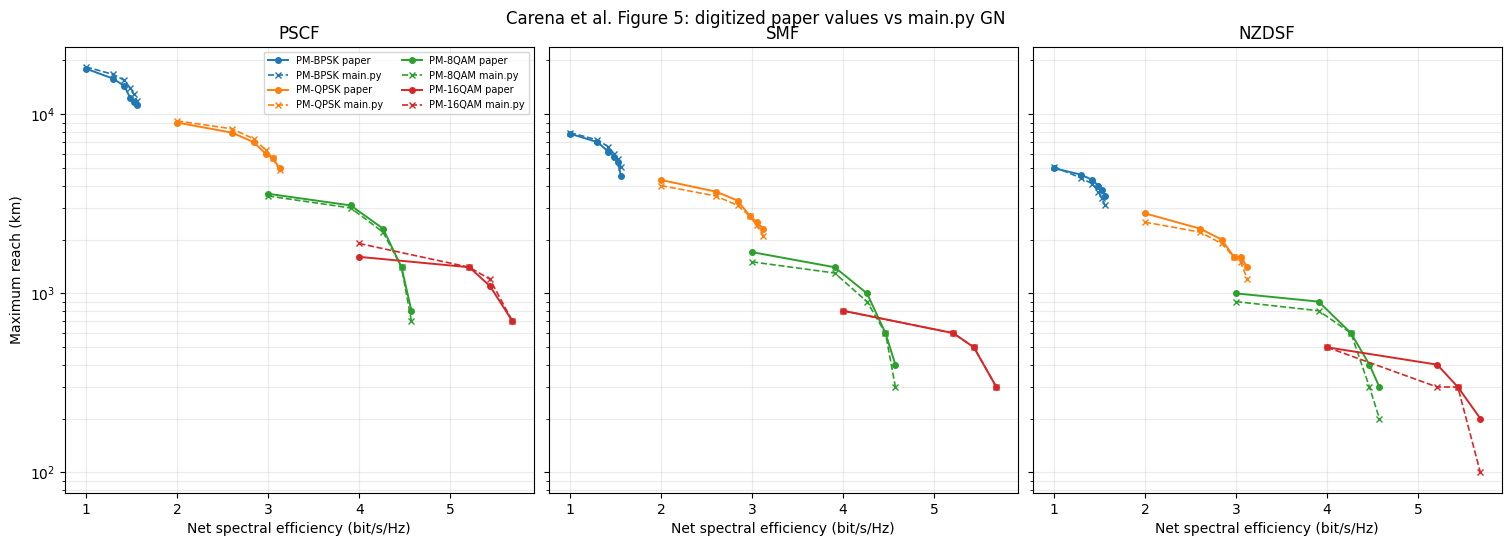

In [9]:
_plot_carena_fig5(figure5)


## 6. 결과 요약

오차율은 `(main.py 계산거리 - 논문 기준거리) / 논문 기준거리 × 100`으로 계산했습니다. 음수이면 `main.py`가 논문 기준거리보다 짧게 예측했다는 뜻입니다.


In [10]:
summary_display = summary.copy()
summary_display['mape_pct'] = summary_display['mape_pct'].map(lambda value: f'{value:.2f}%')
summary_display['bias_pct'] = summary_display['bias_pct'].map(lambda value: f'{value:+.2f}%')
summary_display['reach_rmse_db'] = summary_display['reach_rmse_db'].map(lambda value: f'{value:.3f} dB')
display(summary_display.rename(columns={
    'fiber': '광섬유',
    'points': '비교 점 수',
    'mape_pct': '평균 절대오차',
    'bias_pct': '평균 편차',
    'reach_rmse_db': '거리 RMSE',
}))

for fiber_name in ['PSCF', 'SMF', 'NZDSF']:
    print(f'\n[{fiber_name}: 점별 결과]')
    columns = [
        'modulation', 'spacing_ghz', 'net_spectral_efficiency_bps_hz',
        'reference_reach_km', 'predicted_reach_km',
        'launch_dbm_at_max_reach', 'error_pct',
    ]
    display(
        results.loc[results['fiber'] == fiber_name, columns]
        .rename(columns={
            'modulation': '변조방식',
            'spacing_ghz': '채널 간격 (GHz)',
            'net_spectral_efficiency_bps_hz': '순 스펙트럼 효율 (bit/s/Hz)',
            'reference_reach_km': '논문 기준거리 (km)',
            'predicted_reach_km': 'main.py 거리 (km)',
            'launch_dbm_at_max_reach': '최대거리 launch power (dBm)',
            'error_pct': '오차율 (%)',
        })
        .round(2)
    )


,광섬유,비교 점 수,평균 절대오차,평균 편차,거리 RMSE
0,NZDSF,21,11.21%,-11.02%,0.908 dB
1,PSCF,21,5.48%,+3.11%,0.308 dB
2,SMF,21,5.53%,-2.57%,0.379 dB
3,OVERALL,63,7.41%,-3.49%,0.595 dB



[PSCF: 점별 결과]


,변조방식,채널 간격 (GHz),순 스펙트럼 효율 (bit/s/Hz),논문 기준거리 (km),main.py 거리 (km),최대거리 launch power (dBm),오차율 (%)
21,PM-16QAM,50.000,4.000,"1,600.000","1,900.000",0.350,18.750
22,PM-16QAM,38.400,5.210,"1,400.000","1,400.000",0.100,0.000
23,PM-16QAM,36.800,5.430,"1,100.000","1,200.000",0.050,9.090
24,PM-16QAM,35.200,5.680,700.000,700.000,0.000,0.000
25,PM-8QAM,50.000,3.000,"3,600.000","3,500.000",0.350,-2.780
26,PM-8QAM,38.400,3.910,"3,100.000","3,000.000",0.100,-3.230
27,PM-8QAM,35.200,4.260,"2,300.000","2,200.000",0.000,-4.350
28,PM-8QAM,33.600,4.460,"1,400.000","1,400.000",0.000,0.000
29,PM-8QAM,32.800,4.570,800.000,700.000,-0.050,-12.500
30,PM-BPSK,50.000,1.000,"18,000.000","18,400.000",0.350,2.220



[SMF: 점별 결과]


,변조방식,채널 간격 (GHz),순 스펙트럼 효율 (bit/s/Hz),논문 기준거리 (km),main.py 거리 (km),최대거리 launch power (dBm),오차율 (%)
42,PM-16QAM,50.000,4.000,800.000,800.000,0.750,0.000
43,PM-16QAM,38.400,5.210,600.000,600.000,0.500,0.000
44,PM-16QAM,36.800,5.430,500.000,500.000,0.450,0.000
45,PM-16QAM,35.200,5.680,300.000,300.000,0.400,0.000
46,PM-8QAM,50.000,3.000,"1,700.000","1,500.000",0.750,-11.760
47,PM-8QAM,38.400,3.910,"1,400.000","1,300.000",0.500,-7.140
48,PM-8QAM,35.200,4.260,"1,000.000",900.000,0.400,-10.000
49,PM-8QAM,33.600,4.460,600.000,600.000,0.350,0.000
50,PM-8QAM,32.800,4.570,400.000,300.000,0.300,-25.000
51,PM-BPSK,50.000,1.000,"7,800.000","7,900.000",0.750,1.280



[NZDSF: 점별 결과]


,변조방식,채널 간격 (GHz),순 스펙트럼 효율 (bit/s/Hz),논문 기준거리 (km),main.py 거리 (km),최대거리 launch power (dBm),오차율 (%)
0,PM-16QAM,50.000,4.000,500.000,500.000,-1.200,0.000
1,PM-16QAM,38.400,5.210,400.000,300.000,-1.550,-25.000
2,PM-16QAM,36.800,5.430,300.000,300.000,-1.650,0.000
3,PM-16QAM,35.200,5.680,200.000,100.000,-1.700,-50.000
4,PM-8QAM,50.000,3.000,"1,000.000",900.000,-1.200,-10.000
5,PM-8QAM,38.400,3.910,900.000,800.000,-1.550,-11.110
6,PM-8QAM,35.200,4.260,600.000,600.000,-1.700,0.000
7,PM-8QAM,33.600,4.460,400.000,300.000,-1.750,-25.000
8,PM-8QAM,32.800,4.570,300.000,200.000,-1.800,-33.330
9,PM-BPSK,50.000,1.000,"5,000.000","5,100.000",-1.200,2.000


## 7. 같은 변조방식으로 세 광섬유를 비교하는 예

PM-QPSK, 채널 간격 50 GHz를 예로 들면, 광섬유 입력값만 바꿨을 때 최대거리와 필요한 launch power가 어떻게 달라지는지 볼 수 있습니다.


In [11]:
representative_case = (
    results.loc[
        (results['modulation'] == 'PM-QPSK') & (results['spacing_ghz'] == 50.0),
        ['fiber', 'reference_reach_km', 'predicted_reach_km', 'launch_dbm_at_max_reach', 'error_pct'],
    ]
    .rename(columns={
        'fiber': '광섬유',
        'reference_reach_km': '논문 기준거리 (km)',
        'predicted_reach_km': 'main.py 거리 (km)',
        'launch_dbm_at_max_reach': '선택된 launch power (dBm)',
        'error_pct': '오차율 (%)',
    })
    .round(2)
)
display(representative_case)


,광섬유,논문 기준거리 (km),main.py 거리 (km),선택된 launch power (dBm),오차율 (%)
15,NZDSF,"2,800.000","2,500.000",-1.200,-10.710
36,PSCF,"9,000.000","9,200.000",0.350,2.220
57,SMF,"4,300.000","4,000.000",0.750,-6.980


## 8. NZDSF에서 오차가 상대적으로 큰 이유

NZDSF는 분산이 매우 작고 비선형계수가 가장 큽니다. 그래서 채널 간 상호작용이 강해지고, 단순 closed-form GN 근사식과 논문의 더 상세한 시뮬레이션 결과 사이 차이가 커질 수 있습니다.

또한 이 계산은 100 km 단위로 거리를 고릅니다. 예를 들어 기준거리가 200 km일 때 계산값이 100 km이면, 한 span 차이만으로도 오차가 −50%가 됩니다. 짧은 거리·고차 변조에서 오차율이 크게 보일 수 있는 이유입니다.


In [12]:
worst_cases = (
    results.assign(abs_error_pct=results['error_pct'].abs())
    .sort_values('abs_error_pct', ascending=False)
    .head(8)[['fiber', 'modulation', 'spacing_ghz', 'reference_reach_km', 'predicted_reach_km', 'error_pct']]
    .rename(columns={
        'fiber': '광섬유',
        'modulation': '변조방식',
        'spacing_ghz': '채널 간격 (GHz)',
        'reference_reach_km': '논문 기준거리 (km)',
        'predicted_reach_km': 'main.py 거리 (km)',
        'error_pct': '오차율 (%)',
    })
    .round(2)
)
display(worst_cases)


,광섬유,변조방식,채널 간격 (GHz),논문 기준거리 (km),main.py 거리 (km),오차율 (%)
3,NZDSF,PM-16QAM,35.200,200.000,100.000,-50.000
8,NZDSF,PM-8QAM,32.800,300.000,200.000,-33.330
1,NZDSF,PM-16QAM,38.400,400.000,300.000,-25.000
7,NZDSF,PM-8QAM,33.600,400.000,300.000,-25.000
50,SMF,PM-8QAM,32.800,400.000,300.000,-25.000
21,PSCF,PM-16QAM,50.000,"1,600.000","1,900.000",18.750
20,NZDSF,PM-QPSK,32.000,"1,400.000","1,200.000",-14.290
33,PSCF,PM-BPSK,33.600,"12,300.000","14,000.000",13.820


## 9. 결과 파일 저장

아래 셀을 실행하면 비교 그래프, 점별 결과 CSV, 요약 CSV, 계산 조건 JSON이 `carena_fig5_results` 폴더에 저장됩니다. Colab 왼쪽 파일 창에서 내려받을 수 있습니다.


In [13]:
output_directory = save_carena_fig5_result(figure5, 'carena_fig5_results')
print('저장 위치:', Path(output_directory).resolve())
print('생성 파일:', [path.name for path in sorted(Path(output_directory).iterdir())])


저장 위치: /content/carena_fig5_results
생성 파일: ['carena_fig5_comparison.csv', 'carena_fig5_comparison.png', 'carena_fig5_metadata.json', 'carena_fig5_summary.csv']
